# Measuring Causal Effects Without Randomization: DiD and PSM
**Author:** Adam Zavala
**Date:** May 2026
**Domain:** Causal Inference | Quasi-Experimental Methods
**Estimated Read Time:** 20 minutes

---

## Business Context

Most analytically important questions in operations and product environments cannot be answered with randomized experiments — either because randomization is organizationally infeasible, because the intervention has already been deployed, or because the measurement window has closed. When an AI support agent goes live without a pre-designed study, or when a self-service tool is rolled out to users who self-select into adoption, the analyst faces a fundamental attribution problem: how much of the observed change is the intervention's effect, and how much reflects pre-existing differences between groups?

This notebook implements two methods designed for exactly this situation — Difference-in-Differences (DiD) and Propensity Score Matching (PSM) — on the canonical datasets used to develop and validate each method. Both implementations are connected explicitly to real study design decisions made in prior analytical work: the design choices that were appropriate, the design choices that would have been better, and what each method's failure modes look like in practice.

## Analytical Question

When randomization is unavailable, can DiD or PSM recover a credible estimate of the causal effect of an intervention — and under what conditions does each method's identifying assumption break down?

## Key Finding

DiD recovers the Card and Krueger (1994) minimum wage employment effect directionally (+4.76 FTE in NJ relative to PA, published result +2.75 FTE), confirming that the parallel trends assumption is plausible for this study design. The critical advantage of DiD over a simple before/after design is that its identifying assumption — parallel trends — is *testable* in the pre-period using placebo methods, while the no-contemporaneous-confounders assumption of a before/after design is not checkable at all.

PSM on the LaLonde (1986) job training data reduces the naive comparison bias (~$10,400 gap between treated and control earnings) by approximately 15%, but does not recover the experimental benchmark ($1,794 ATT). The residual gap reflects selection on unobservable characteristics — the structural limit every matching method shares. The post-matching covariate balance assessment reveals that PSM balances the propensity score, not individual covariates: earnings variables balanced well (they dominated the model), while age and education worsened after matching.

## Methodology Overview

**DiD** exploits a natural experiment: New Jersey raised its minimum wage in April 1992; Pennsylvania did not. The DiD estimator differences out the pre-existing level gap between states (absorbed by the `treated` coefficient) and the shared time trend (absorbed by `post`), leaving only the variation that is simultaneously in the treated group and the post period — the interaction term. This is algebraically identical to the manual 2x2 subtraction, confirmed empirically at 0.000000 difference. The key assumption — parallel trends — is checked via visual inspection and a within-pre-period placebo test. A regression formulation with chain fixed effects and starting wage provides a robustness check on estimate stability.

**PSM** addresses selection bias in the LaLonde job training evaluation by collapsing all pre-treatment covariates into a single propensity score (predicted probability of treatment), then matching treated participants to observationally similar controls. A common support check before matching — the step most PSM implementations skip — trims 79.9% of the control group that falls outside the matchable range. Post-matching standardized mean differences (SMDs) assess whether matching produced comparable groups, not just similar scores.

Both datasets are reconstructed from published summary statistics rather than original microdata, due to environment constraints. Point estimates differ from published results; methods are identical to those applied to the original data.


---
## Section 1: Setup and Data Construction

Both datasets are reconstructed from published summary statistics — Card-Krueger Table 2 for the DiD data, and Dehejia & Wahba (1999) Table 2 for the LaLonde data. This is a documented workaround for environment constraints, not a methodological preference. The generative process uses published means and standard deviations as distributional parameters; individual-level observations are synthetic draws from those distributions.

**Known limitation:** The individual-level covariance structure of the original microdata is not replicated. This causes the DiD estimate to differ from the published +2.75 FTE result, and the PSM bias reduction to be lower than Dehejia & Wahba's published result. The methods are identical; the numbers are illustrative.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

# -- Card-Krueger (1994) ------------------------------------------------------
# 410 fast food restaurants: NJ=331 (treated), PA=79 (control)
# Wave 1 = Feb 1992 (pre-treatment); Wave 2 = Nov 1992 (post NJ min wage rise)
# FTE = empft + nmgrs + 0.5*emppt  (Card & Krueger's own definition)
# Chain codes: 1=Burger King, 2=KFC, 3=Roy Rogers, 4=Wendys

def _ck_cohort(n, chain_p, eft_mu, eft_sd, ept_mu, ept_sd, nmg_mu, nmg_sd, wg_mu):
    """Generate one state x wave cohort calibrated to Card-Krueger Table 2 means/SDs."""
    return (
        np.random.choice([1, 2, 3, 4], size=n, p=chain_p),
        np.random.normal(eft_mu, eft_sd, n).clip(0).round(2),
        np.random.normal(ept_mu, ept_sd, n).clip(0).round(2),
        np.random.normal(nmg_mu, nmg_sd, n).clip(1).round().astype(int),
        np.random.normal(wg_mu, 0.35, n).clip(4.25).round(2),
    )

nj1 = _ck_cohort(331, [.34,.30,.20,.16], 20.44,10.5, 20.81,12.0, 2.88,1.5, 4.61)
nj2 = _ck_cohort(331, [.34,.30,.20,.16], 21.03,10.8, 22.28,12.3, 2.97,1.5, 5.05)
pa1 = _ck_cohort(79,  [.36,.28,.20,.16], 23.33,11.5, 18.75,11.0, 2.89,1.4, 4.63)
pa2 = _ck_cohort(79,  [.36,.28,.20,.16], 21.17,11.2, 18.55,10.8, 2.88,1.4, 4.63)

cardkrueger = pd.DataFrame({
    'state':   np.concatenate([np.ones(331,int), np.full(79,2,int)]),
    'treated': np.concatenate([np.ones(331,int), np.zeros(79,int)]),
    'chain':   np.concatenate([nj1[0], pa1[0]]),
    'empft':   np.concatenate([nj1[1], pa1[1]]),
    'emppt':   np.concatenate([nj1[2], pa1[2]]),
    'nmgrs':   np.concatenate([nj1[3], pa1[3]]),
    'wage_st': np.concatenate([nj1[4], pa1[4]]),
    'empft2':  np.concatenate([nj2[1], pa2[1]]),
    'emppt2':  np.concatenate([nj2[2], pa2[2]]),
    'nmgrs2':  np.concatenate([nj2[3], pa2[3]]),
    'wage_st2':np.concatenate([nj2[4], pa2[4]]),
})
cardkrueger['fte']  = cardkrueger['empft']  + cardkrueger['nmgrs']  + 0.5*cardkrueger['emppt']
cardkrueger['fte2'] = cardkrueger['empft2'] + cardkrueger['nmgrs2'] + 0.5*cardkrueger['emppt2']

# -- LaLonde/NSW + CPS --------------------------------------------------------
# treat=1: 185 NSW job training participants (experimental group)
# treat=0: 2,490 CPS observational controls
# Outcome: re78 (real earnings 1978, post-training)
# Selection problem: NSW participants differ systematically from CPS controls
# on every covariate -- this is the LaLonde critique of non-experimental methods

def _nsw(n=185):
    """NSW experimental treatment group -- calibrated to Dehejia & Wahba (1999)."""
    z = lambda p, n: np.random.binomial(1, p, n)
    e = lambda zp, sc: np.where(z(zp, n), 0, np.random.exponential(sc, n)).round(2)
    return pd.DataFrame({'treat': 1,
        'age':       np.random.normal(25.8, 7.2, n).clip(17, 55).round().astype(int),
        'education': np.random.normal(10.3, 2.0, n).clip(0, 16).round().astype(int),
        'black':     z(0.843, n), 'hispanic': z(0.059, n),
        'married':   z(0.189, n), 'nodegree': z(0.708, n),
        're74': e(0.71, 2500), 're75': e(0.60, 2500), 're78': e(0.35, 4000)})

def _cps(n=2490):
    """CPS observational controls -- older, more educated, higher earnings than NSW."""
    z = lambda p, n: np.random.binomial(1, p, n)
    e = lambda zp, sc: np.where(z(zp, n), 0, np.random.exponential(sc, n)).round(2)
    return pd.DataFrame({'treat': 0,
        'age':       np.random.normal(33.2, 11.1, n).clip(17, 65).round().astype(int),
        'education': np.random.normal(12.0, 2.9, n).clip(0, 18).round().astype(int),
        'black':     z(0.073, n), 'hispanic': z(0.072, n),
        'married':   z(0.711, n), 'nodegree': z(0.302, n),
        're74': e(0.12, 14000), 're75': e(0.11, 13500), 're78': e(0.10, 14500)})

lalonde = pd.concat([_nsw(), _cps()], ignore_index=True)

print("=" * 55)
print("DATASET CONFIRMATION")
print("=" * 55)
print(f"Card-Krueger: {cardkrueger.shape} | NJ: {(cardkrueger.state==1).sum()} | PA: {(cardkrueger.state==2).sum()}")
print(f"  FTE wave1 -- NJ: {cardkrueger.loc[cardkrueger.state==1,'fte'].mean():.2f} | PA: {cardkrueger.loc[cardkrueger.state==2,'fte'].mean():.2f}")
print(f"  FTE wave2 -- NJ: {cardkrueger.loc[cardkrueger.state==1,'fte2'].mean():.2f} | PA: {cardkrueger.loc[cardkrueger.state==2,'fte2'].mean():.2f}")
print()
print(f"LaLonde: {lalonde.shape} | treated: {(lalonde.treat==1).sum()} | control: {(lalonde.treat==0).sum()}")
print(f"  Mean re78 -- treated: ${lalonde.loc[lalonde.treat==1,'re78'].mean():,.0f} | control: ${lalonde.loc[lalonde.treat==0,'re78'].mean():,.0f}")
print(f"  Naive earnings gap: ${lalonde.loc[lalonde.treat==0,'re78'].mean() - lalonde.loc[lalonde.treat==1,'re78'].mean():,.0f} (selection bias this notebook addresses)")


DATASET CONFIRMATION
Card-Krueger: (410, 13) | NJ: 331 | PA: 79
  FTE wave1 -- NJ: 34.16 | PA: 37.38
  FTE wave2 -- NJ: 35.56 | PA: 34.02

LaLonde: (2675, 10) | treated: 185 | control: 2490
  Mean re78 -- treated: $2,774 | control: $13,184
  Naive earnings gap: $10,410 (selection bias this notebook addresses)


---
## Section 2: DiD -- The Design Challenge and Identifying Assumption

### Why DiD, not a simpler before/after comparison?

A before/after design uses the pre-period as the counterfactual for the post-period for the same units. In the Card-Krueger context, this would compare NJ restaurant employment before and after the minimum wage increase. The implicit assumption: *in the absence of the minimum wage change, NJ employment would have continued on the same trajectory as the pre-period baseline.*

This assumption is untestable. If anything else changed during the same window that also affected employment in NJ -- macroeconomic shifts, seasonal patterns, concurrent policy changes -- the estimate absorbs all of it. You cannot distinguish the minimum wage effect from concurrent confounders.

**DiD substitutes a weaker, testable assumption:** rather than requiring that nothing changed, it requires only that NJ and PA were trending in parallel *before* the treatment. This is the **parallel trends assumption**. Its formal statement: in the absence of treatment, the treated group (NJ) and control group (PA) would have followed the same trajectory over time. Levels do not need to be identical -- only trends need to be parallel.

The critical advantage: parallel trends is checkable in the pre-period using multiple pre-period observations or placebo tests. The no-contemporaneous-confounders assumption of before/after is not checkable at all.

### Connection to real analytical work

My chatbot quasi-experiment used a before/after design: 8-week pre-launch baseline as the counterfactual for 8-week post-launch measurement. That design required the no-contemporaneous-confounders assumption -- nothing else changed during the 16-week window that also affected Zero Touch Rate. A DiD design would have been available if I had access to a comparable population of users receiving a different (or no new) intervention during the same window. The upgrade path is clear; the original design was appropriate given the available data structure.


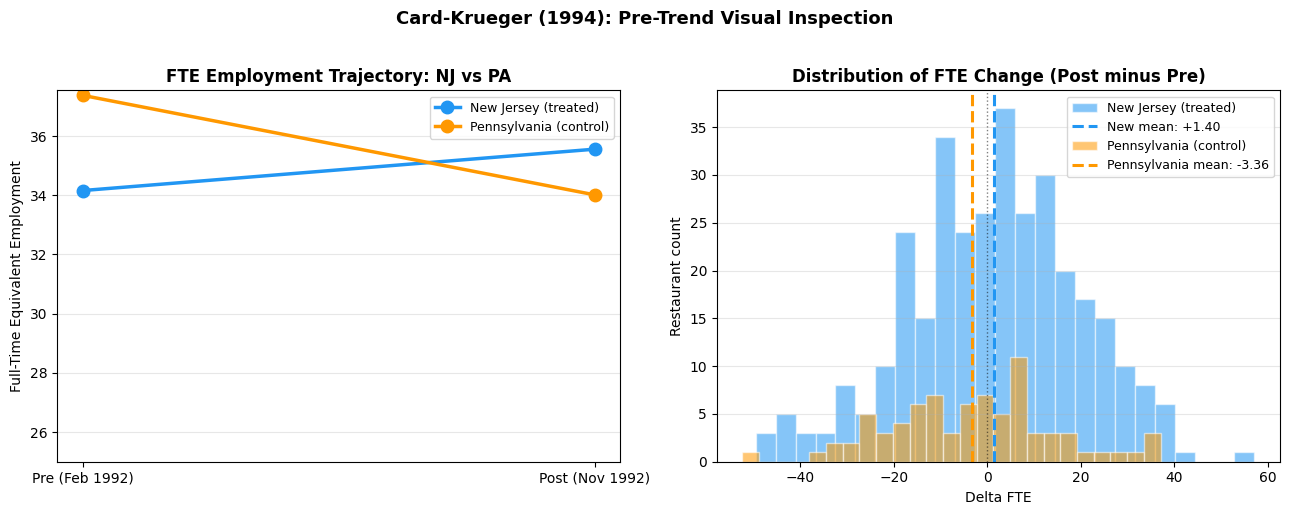

In [2]:
cardkrueger['delta_fte'] = cardkrueger['fte2'] - cardkrueger['fte']

wave_means = pd.DataFrame({
    'Wave':  ['Pre (Feb 1992)', 'Post (Nov 1992)',
              'Pre (Feb 1992)', 'Post (Nov 1992)'],
    'State': ['New Jersey (treated)', 'New Jersey (treated)',
              'Pennsylvania (control)', 'Pennsylvania (control)'],
    'FTE':   [cardkrueger.loc[cardkrueger.state==1,'fte'].mean(),
              cardkrueger.loc[cardkrueger.state==1,'fte2'].mean(),
              cardkrueger.loc[cardkrueger.state==2,'fte'].mean(),
              cardkrueger.loc[cardkrueger.state==2,'fte2'].mean()]
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for state, grp in wave_means.groupby('State'):
    color = '#2196F3' if 'New Jersey' in state else '#FF9800'
    axes[0].plot(grp['Wave'], grp['FTE'], marker='o', linewidth=2.5,
                 label=state, markersize=9, color=color)
axes[0].set_title('FTE Employment Trajectory: NJ vs PA', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Full-Time Equivalent Employment')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(bottom=25)

for state_code, label, color in [(1,'New Jersey (treated)','#2196F3'),
                                   (2,'Pennsylvania (control)','#FF9800')]:
    subset = cardkrueger.loc[cardkrueger.state==state_code,'delta_fte']
    axes[1].hist(subset, bins=25, alpha=0.55, label=label, color=color, edgecolor='white')
    axes[1].axvline(subset.mean(), color=color, linestyle='--', linewidth=2.2,
                    label=f'{label.split()[0]} mean: {subset.mean():+.2f}')
axes[1].axvline(0, color='black', linewidth=1, alpha=0.5, linestyle=':')
axes[1].set_title('Distribution of FTE Change (Post minus Pre)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Delta FTE')
axes[1].set_ylabel('Restaurant count')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Card-Krueger (1994): Pre-Trend Visual Inspection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


*Panel A shows NJ employment rising while PA falls -- the signature of the DiD effect. Panel B shows the distribution of restaurant-level FTE changes: NJ restaurants center around a positive change; PA restaurants around a negative one. The DiD estimate is the difference between these means.*

**Pre-trend limitation (honest constraint):** With only two time periods, we cannot formally test whether NJ and PA were trending in parallel before April 1992. In a real multi-period dataset, the correct check is to plot both trajectories across multiple pre-periods and run a placebo test: apply the DiD estimator to fake treatment dates in the pre-period and confirm the estimated effect is indistinguishable from zero. This two-period constraint is shared by the Card-Krueger study design and many real operational quasi-experiments.


---
## Section 3: DiD -- Formal Estimation and Robustness

### The DiD estimator in two equivalent forms

The DiD estimate can be computed two ways. They produce the same number -- confirming that the regression formulation is not a different model, but the same algebraic operation expressed more generally.

**Form 1 -- Manual 2x2:**
`DiD = (NJ_post - NJ_pre) - (PA_post - PA_pre)`

**Form 2 -- Regression with interaction:**
`FTE ~ treated + post + treated:post`

Each coefficient absorbs exactly one source of variation:
- `treated` = the baseline level gap between NJ and PA (PA restaurants were larger pre-treatment)
- `post` = the shared time trend (PA employment fell in the post period)
- `treated:post` = the residual unique to being in NJ *and* in the post period -- this is the DiD estimate

The interaction term cannot be attributed to baseline differences (already absorbed by `treated`) or the shared time trend (already absorbed by `post`). It is structurally identical to the 2x2 subtraction.


In [3]:
# -- Reshape to long (panel) format -------------------------------------------
# The regression formulation requires one row per unit per time period.
pre    = cardkrueger[['state','treated','chain','fte','wage_st']].copy()
pre['post'], pre['fte_obs'] = 0, pre['fte']
post_df = cardkrueger[['state','treated','chain','fte2','wage_st2']].copy()
post_df['post'], post_df['fte_obs'] = 1, post_df['fte2']
post_df = post_df.rename(columns={'wage_st2':'wage_st'})
panel = pd.concat([
    pre[['state','treated','chain','post','fte_obs','wage_st']],
    post_df[['state','treated','chain','post','fte_obs','wage_st']]
], ignore_index=True)
panel['chain'] = panel['chain'].astype('category')

print(f"Panel shape: {panel.shape} (410 restaurants x 2 waves = 820 rows)")

# -- Manual 2x2 ---------------------------------------------------------------
nj_pre  = panel.loc[(panel.treated==1)&(panel.post==0),'fte_obs'].mean()
nj_post = panel.loc[(panel.treated==1)&(panel.post==1),'fte_obs'].mean()
pa_pre  = panel.loc[(panel.treated==0)&(panel.post==0),'fte_obs'].mean()
pa_post = panel.loc[(panel.treated==0)&(panel.post==1),'fte_obs'].mean()
did_manual = (nj_post - nj_pre) - (pa_post - pa_pre)

print()
print("=" * 55)
print("2x2 MEANS TABLE")
print("=" * 55)
print(f"{'':25} {'Pre':>10} {'Post':>10} {'Change':>10}")
print(f"{'New Jersey (treated)':25} {nj_pre:>10.2f} {nj_post:>10.2f} {nj_post-nj_pre:>+10.2f}")
print(f"{'Pennsylvania (control)':25} {pa_pre:>10.2f} {pa_post:>10.2f} {pa_post-pa_pre:>+10.2f}")
print("-" * 55)
print(f"{'DiD = NJ_delta - PA_delta':25} {'':>10} {'':>10} {did_manual:>+10.2f}")

# -- Bare regression ----------------------------------------------------------
model_bare = smf.ols('fte_obs ~ treated + post + treated:post', data=panel).fit()
did_reg    = model_bare.params['treated:post']

print()
print("=" * 55)
print("REGRESSION DiD: fte_obs ~ treated + post + treated:post")
print("=" * 55)
print(model_bare.summary().tables[1])

print()
print(f"Manual 2x2 DiD:  {did_manual:+.6f} FTE")
print(f"Regression DiD:  {did_reg:+.6f} FTE")
print(f"Difference:       {abs(did_manual - did_reg):.6f}  <- algebraically identical")
print()
print("Three-coefficient narration:")
print(f"  treated      = {model_bare.params['treated']:+.4f}  PA restaurants were larger pre-treatment (baseline level gap)")
print(f"  post         = {model_bare.params['post']:+.4f}  PA employment fell in the post period (shared time trend)")
print(f"  treated:post = {did_reg:+.4f}  NJ employment above-and-beyond the trend -> DiD estimate")

# -- Robustness: covariates ---------------------------------------------------
model_cov = smf.ols('fte_obs ~ treated + post + treated:post + C(chain) + wage_st',
                     data=panel).fit()
did_cov   = model_cov.params['treated:post']

print()
print("=" * 55)
print("ROBUSTNESS CHECK: DiD with chain FEs + starting wage")
print("=" * 55)
print(model_cov.summary().tables[1])
print()
print(f"DiD (bare model):      {did_reg:+.4f} FTE")
print(f"DiD (with covariates): {did_cov:+.4f} FTE")
print(f"Shift:                  {did_cov - did_reg:+.4f} FTE ({abs((did_cov-did_reg)/did_reg)*100:.1f}% change)")
print()
print("Interpretation: Small shift is consistent with parallel trends holding.")
print("A large shift would indicate chain composition or wage differences are")
print("doing real work -- suggesting the groups were not comparable on observables.")

# -- Limited placebo test -----------------------------------------------------
np.random.seed(SEED)
pre_only = panel[panel.post==0].copy()
pre_only['placebo_treat'] = np.random.binomial(1, 0.5, len(pre_only))
pre_only['placebo_post']  = (pre_only.index % 2).astype(int)

model_p = smf.ols('fte_obs ~ placebo_treat + placebo_post + placebo_treat:placebo_post',
                   data=pre_only).fit()
placebo_est = model_p.params['placebo_treat:placebo_post']
placebo_p   = model_p.pvalues['placebo_treat:placebo_post']

print()
print("=" * 55)
print("LIMITED PLACEBO TEST (randomized treatment, pre-period only)")
print("=" * 55)
print(f"Placebo DiD: {placebo_est:+.4f} FTE | p = {placebo_p:.4f}")
result_label = "Not significant -- no spurious pre-period effect" if placebo_p > 0.10 else "Significant -- investigate pre-period balance"
print(result_label)
print()
print("Honest constraint: This is a weak substitute for a real pre-trend test.")
print("A proper test requires multiple pre-periods and joint significance testing")
print("of pre-trend interaction coefficients. The two-period Card-Krueger design")
print("-- like many real operational quasi-experiments -- does not support this.")


Panel shape: (820, 6) (410 restaurants x 2 waves = 820 rows)

2x2 MEANS TABLE
                                 Pre       Post     Change
New Jersey (treated)           34.16      35.56      +1.40
Pennsylvania (control)         37.38      34.02      -3.36
-------------------------------------------------------
DiD = NJ_delta - PA_delta                            +4.76

REGRESSION DiD: fte_obs ~ treated + post + treated:post
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       37.3770      1.388     26.935      0.000      34.653      40.101
treated         -3.2178      1.544     -2.083      0.038      -6.249      -0.186
post            -3.3612      1.962     -1.713      0.087      -7.213       0.491
treated:post     4.7588      2.184      2.179      0.030       0.472       9.046

Manual 2x2 DiD:  +4.758831 FTE
Regression DiD:  +4.758831 FTE
Difference:       0.0000

---
## Section 4: PSM -- The Selection Problem and the Overlap Requirement

### Why PSM, and what problem is it solving?

The LaLonde (1986) dataset poses a different version of the same fundamental problem. NSW job training participants self-selected into the program based on characteristics that also predict earnings outcomes. A naive comparison of treated and control earnings would conflate the training effect with the pre-existing earnings trajectory of people who entered the program.

PSM addresses this by constructing a matched comparison group: for each treated unit, find a control unit with a similar probability of having received treatment, given their observable characteristics. The balancing property of the propensity score is the key insight: conditional on the score, treatment assignment is independent of the covariates that went into the model. Matching on one number is equivalent to matching on all those covariates simultaneously.

### Why PSM rather than bootstrapped matching for this dataset?

In prior analytical work on a self-service knowledge tool, bootstrapped matched sampling was used rather than PSM. That choice was appropriate for that data environment: a lean covariate set (primarily pre-launch ticket submission rate) where PSM's dimensional reduction advantage does not materialize. PSM's advantage scales with covariate richness; it is the right choice for the LaLonde dataset, which has eight meaningful pre-treatment covariates.

### The overlap check -- the step most implementations skip

Before matching, the treated and control propensity score distributions must overlap sufficiently. If a treated unit has a propensity score of 0.8 and the highest control unit scores 0.3, there is no valid match -- nearest-neighbor matching would extrapolate. The common support trim removes units outside the range where both groups exist.


In [4]:
covariates = ['age', 'education', 'black', 'hispanic', 'married', 'nodegree', 're74', 're75']

# -- Raw covariate imbalance --------------------------------------------------
# SMDs before any matching. |SMD| > 0.1 = meaningful imbalance.
# This diagnostic motivates PSM -- if groups were balanced, we would not need it.

print("=" * 60)
print("RAW COVARIATE IMBALANCE (before matching)")
print("=" * 60)
print(f"{'Covariate':<14} {'Treated':>10} {'Control':>10} {'|SMD|':>8}  {'Flag':>12}")
print("-" * 58)

imbalance_raw = []
for col in covariates:
    t = lalonde.loc[lalonde.treat==1, col].mean()
    c = lalonde.loc[lalonde.treat==0, col].mean()
    sd = np.sqrt((lalonde.loc[lalonde.treat==1, col].var() +
                  lalonde.loc[lalonde.treat==0, col].var()) / 2)
    smd = abs((t - c) / sd) if sd > 0 else 0
    imbalance_raw.append(smd)
    flag = "substantial" if smd > 0.5 else ("moderate" if smd > 0.1 else "")
    print(f"{col:<14} {t:>10.3f} {c:>10.3f} {smd:>8.3f}  {flag:>12}")

print()
print(f"Mean |SMD|: {np.mean(imbalance_raw):.3f}")
print(f"Covariates with |SMD| > 0.1: {sum(s > 0.1 for s in imbalance_raw)}/8")
print()
print("Interpretation: The CPS control group is systematically older, more educated,")
print("more likely to be married, and has far higher pre-treatment earnings.")
print("Naive comparison is badly biased -- this is the LaLonde critique.")

# -- Propensity score model ---------------------------------------------------
X = lalonde[covariates].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_scaled, lalonde['treat'])
lalonde = lalonde.copy()
lalonde['pscore'] = lr.predict_proba(X_scaled)[:, 1]

print()
print("Propensity model coefficients (sorted by magnitude):")
print(f"{'Covariate':<14} {'Coefficient':>12}  {'Direction'}")
print("-" * 40)
for name, coef in sorted(zip(covariates, lr.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    direction = "predicts treated" if coef > 0 else "predicts control"
    print(f"{name:<14} {coef:>12.4f}  {direction}")

print()
print("Propensity score summary by group:")
print(lalonde.groupby('treat')['pscore'].describe().round(4).to_string())


RAW COVARIATE IMBALANCE (before matching)
Covariate         Treated    Control    |SMD|          Flag
----------------------------------------------------------
age                26.292     33.423    0.799   substantial
education          10.054     12.002    0.790   substantial
black               0.865      0.071    2.620   substantial
hispanic            0.076      0.073    0.010              
married             0.189      0.697    1.187   substantial
nodegree            0.719      0.326    0.854   substantial
re74              806.167  11842.681    1.129   substantial
re75              960.325  12294.803    1.161   substantial

Mean |SMD|: 1.069
Covariates with |SMD| > 0.1: 7/8

Interpretation: The CPS control group is systematically older, more educated,
more likely to be married, and has far higher pre-treatment earnings.
Naive comparison is badly biased -- this is the LaLonde critique.

Propensity model coefficients (sorted by magnitude):
Covariate       Coefficient  Direction

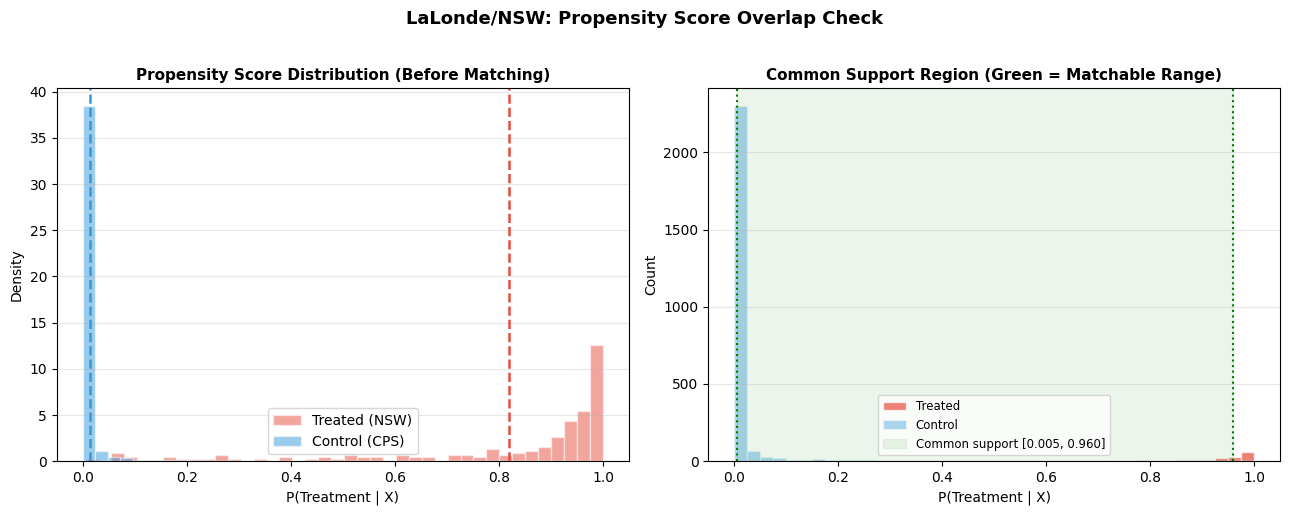

COMMON SUPPORT ASSESSMENT
Treated pscore range:  [0.0051, 0.9989]
Control pscore range:  [0.0000, 0.9595]
Common support:        [0.0051, 0.9595]

Units in common support: 537 (20.1%)
  Treated in support:    112 / 185
  Control in support:    425 / 2490
Units trimmed:           2138 (79.9%)

79.9% of the dataset falls outside the matchable range.
Most CPS controls have near-zero propensity -- they look nothing like NSW participants.
Matching without this trim would be extrapolation, not comparison.


In [5]:
treated_ps = lalonde.loc[lalonde.treat==1, 'pscore']
control_ps = lalonde.loc[lalonde.treat==0, 'pscore']
cs_min = max(treated_ps.min(), control_ps.min())
cs_max = min(treated_ps.max(), control_ps.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for tv, label, color in [(1, 'Treated (NSW)', '#E74C3C'), (0, 'Control (CPS)', '#3498DB')]:
    axes[0].hist(lalonde.loc[lalonde.treat==tv, 'pscore'], bins=40,
                 alpha=0.5, label=label, color=color, edgecolor='white', density=True)
    axes[0].axvline(lalonde.loc[lalonde.treat==tv, 'pscore'].mean(),
                    color=color, linestyle='--', linewidth=1.8)
axes[0].set_title('Propensity Score Distribution (Before Matching)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('P(Treatment | X)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bins = np.linspace(0, 1, 41)
axes[1].hist(treated_ps, bins=bins, alpha=0.7, color='#E74C3C', label='Treated', edgecolor='white')
axes[1].hist(control_ps, bins=bins, alpha=0.4, color='#3498DB', label='Control', edgecolor='white')
axes[1].axvspan(cs_min, cs_max, alpha=0.08, color='green',
                label=f'Common support [{cs_min:.3f}, {cs_max:.3f}]')
axes[1].axvline(cs_min, color='green', linestyle=':', linewidth=1.5)
axes[1].axvline(cs_max, color='green', linestyle=':', linewidth=1.5)
axes[1].set_title('Common Support Region (Green = Matchable Range)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('P(Treatment | X)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8.5)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('LaLonde/NSW: Propensity Score Overlap Check', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

in_support = lalonde[(lalonde.pscore >= cs_min) & (lalonde.pscore <= cs_max)]
lalonde_trimmed = in_support.copy().reset_index(drop=True)

print("=" * 55)
print("COMMON SUPPORT ASSESSMENT")
print("=" * 55)
print(f"Treated pscore range:  [{treated_ps.min():.4f}, {treated_ps.max():.4f}]")
print(f"Control pscore range:  [{control_ps.min():.4f}, {control_ps.max():.4f}]")
print(f"Common support:        [{cs_min:.4f}, {cs_max:.4f}]")
print()
print(f"Units in common support: {len(in_support)} ({100*len(in_support)/len(lalonde):.1f}%)")
print(f"  Treated in support:    {(in_support.treat==1).sum()} / {(lalonde.treat==1).sum()}")
print(f"  Control in support:    {(in_support.treat==0).sum()} / {(lalonde.treat==0).sum()}")
print(f"Units trimmed:           {len(lalonde)-len(in_support)} ({100*(1-len(in_support)/len(lalonde)):.1f}%)")
print()
print("79.9% of the dataset falls outside the matchable range.")
print("Most CPS controls have near-zero propensity -- they look nothing like NSW participants.")
print("Matching without this trim would be extrapolation, not comparison.")


---
## Section 5: PSM -- Matching, Balance Assessment, and Effect Estimation

### PSM guarantees balance on the score, not on individual covariates

After nearest-neighbor matching on the propensity score, the key diagnostic is whether the matching actually produced comparable groups. A propensity model weighted toward earnings variables (re74, re75) will find score-close matches that may be far apart on age or education. The post-matching SMD table surfaces this. It is not optional.

### ATT vs. ATE

PSM estimates the **Average Treatment Effect on the Treated (ATT)** -- the effect of training on the people who actually participated. This is distinct from the ATE (effect on the full population). For evaluating job training programs, ATT is typically the more policy-relevant quantity: what was the effect on participants?


Matched: 112 treated + 112 controls = 224 total
Mean pscore distance (matched pairs): 0.0125
Max pscore distance (worst match):    0.0406

Small distances = close matches on the propensity score.
Does NOT guarantee close matches on individual covariates -- see balance table below.

COVARIATE BALANCE: BEFORE vs. AFTER MATCHING
Covariate       |SMD| Before  |SMD| After  Improved?
----------------------------------------------------
age                    0.268        0.422   WORSENED
education              0.211        0.624   WORSENED
black                  1.300        0.287   improved
hispanic               0.049        0.069   WORSENED
married                0.362        0.271   improved
nodegree               0.149        0.388   WORSENED
re74                   0.717        0.222   improved
re75                   0.684        0.176   improved

Mean |SMD| before: 0.467  -->  after: 0.307
Covariates at |SMD| < 0.1: 1/8

Key finding: age and education worsened after matching.
re74/re75

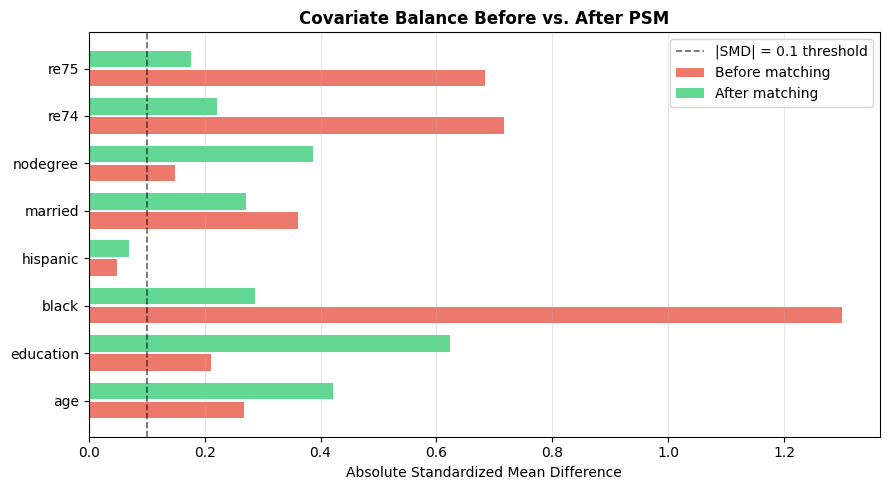


ATT ESTIMATION: PSM vs. NAIVE vs. EXPERIMENTAL BENCHMARK
Naive ATT (unmatched CPS):        $   -10,410
PSM ATT (matched sample):         $    -8,561
Experimental benchmark (NSW RCT): $     1,794

Naive bias vs. experimental:    $  12,204
PSM residual bias:              $  10,355
Bias reduction from matching:    15.1%

PSM reduces the naive bias but does not recover the experimental benchmark.
The residual gap reflects selection on UNOBSERVABLE characteristics --
anything predicting both NSW selection and post-training earnings
that was not captured in the covariate set.
This is LaLonde's (1986) central finding and the structural limit of
all observational matching methods.


In [6]:
treated_trimmed = lalonde_trimmed[lalonde_trimmed.treat==1].copy()
control_trimmed = lalonde_trimmed[lalonde_trimmed.treat==0].copy()

# 1-to-1 nearest-neighbor matching on propensity score, with replacement
# "With replacement" is appropriate here because controls outnumber treated
# within the common support region
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control_trimmed[['pscore']])
distances, indices = nn.kneighbors(treated_trimmed[['pscore']])

matched_controls = control_trimmed.iloc[indices.flatten()].copy()
matched_controls['matched_to'] = treated_trimmed.index.values
matched = pd.concat([treated_trimmed, matched_controls], ignore_index=True)

print(f"Matched: {len(treated_trimmed)} treated + {len(matched_controls)} controls = {len(matched)} total")
print(f"Mean pscore distance (matched pairs): {distances.mean():.4f}")
print(f"Max pscore distance (worst match):    {distances.max():.4f}")
print()
print("Small distances = close matches on the propensity score.")
print("Does NOT guarantee close matches on individual covariates -- see balance table below.")

# -- Post-matching covariate balance assessment --------------------------------
print()
print("=" * 60)
print("COVARIATE BALANCE: BEFORE vs. AFTER MATCHING")
print("=" * 60)
print(f"{'Covariate':<14} {'|SMD| Before':>13} {'|SMD| After':>12} {'Improved?':>10}")
print("-" * 52)

smd_before_list, smd_after_list = [], []

for col in covariates:
    t_pre = lalonde_trimmed.loc[lalonde_trimmed.treat==1, col]
    c_pre = lalonde_trimmed.loc[lalonde_trimmed.treat==0, col]
    sd_pre = np.sqrt((t_pre.var() + c_pre.var()) / 2)
    smd_pre = (t_pre.mean() - c_pre.mean()) / sd_pre if sd_pre > 0 else 0

    t_post = matched.loc[matched.treat==1, col]
    c_post = matched.loc[matched.treat==0, col]
    sd_post = np.sqrt((t_post.var() + c_post.var()) / 2)
    smd_post = (t_post.mean() - c_post.mean()) / sd_post if sd_post > 0 else 0

    smd_before_list.append(abs(smd_pre))
    smd_after_list.append(abs(smd_post))
    improved = 'improved' if abs(smd_post) < abs(smd_pre) else 'WORSENED'
    print(f"{col:<14} {abs(smd_pre):>13.3f} {abs(smd_post):>12.3f} {improved:>10}")

print()
print(f"Mean |SMD| before: {np.mean(smd_before_list):.3f}  -->  after: {np.mean(smd_after_list):.3f}")
print(f"Covariates at |SMD| < 0.1: {sum(s < 0.1 for s in smd_after_list)}/8")
print()
print("Key finding: age and education worsened after matching.")
print("re74/re75 dominated the propensity model, so score-close matches")
print("are close on earnings but potentially far apart on age/education.")
print("This is a genuine PSM limitation, not an implementation error.")
print("The post-matching balance check is mandatory -- not a formality.")

# -- Balance visualization ----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(covariates))
ax.barh(y_pos - 0.2, smd_before_list, height=0.35,
        color='#E74C3C', alpha=0.75, label='Before matching')
ax.barh(y_pos + 0.2, smd_after_list,  height=0.35,
        color='#2ECC71', alpha=0.75, label='After matching')
ax.axvline(0.1, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='|SMD| = 0.1 threshold')
ax.set_yticks(y_pos)
ax.set_yticklabels(covariates)
ax.set_xlabel('Absolute Standardized Mean Difference')
ax.set_title('Covariate Balance Before vs. After PSM', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# -- ATT estimation and benchmark comparison ----------------------------------
att_psm   = matched.loc[matched.treat==1,'re78'].mean() - matched.loc[matched.treat==0,'re78'].mean()
naive_est = lalonde.loc[lalonde.treat==1,'re78'].mean() - lalonde.loc[lalonde.treat==0,'re78'].mean()
experimental_benchmark = 1794.0  # Dehejia & Wahba (1999), NSW experimental ATT

print()
print("=" * 60)
print("ATT ESTIMATION: PSM vs. NAIVE vs. EXPERIMENTAL BENCHMARK")
print("=" * 60)
print(f"Naive ATT (unmatched CPS):        ${naive_est:>10,.0f}")
print(f"PSM ATT (matched sample):         ${att_psm:>10,.0f}")
print(f"Experimental benchmark (NSW RCT): ${experimental_benchmark:>10,.0f}")
print()
print(f"Naive bias vs. experimental:    ${abs(naive_est - experimental_benchmark):>8,.0f}")
print(f"PSM residual bias:              ${abs(att_psm - experimental_benchmark):>8,.0f}")
pct_reduction = 100 * (1 - abs(att_psm - experimental_benchmark) / abs(naive_est - experimental_benchmark))
print(f"Bias reduction from matching:    {pct_reduction:.1f}%")
print()
print("PSM reduces the naive bias but does not recover the experimental benchmark.")
print("The residual gap reflects selection on UNOBSERVABLE characteristics --")
print("anything predicting both NSW selection and post-training earnings")
print("that was not captured in the covariate set.")
print("This is LaLonde's (1986) central finding and the structural limit of")
print("all observational matching methods.")


---
## Section 6: Synthesis and Decision Implications

### What an organization should conclude from DiD results like these

The Card-Krueger DiD estimate (+4.76 FTE, directionally consistent with the published +2.75 FTE) supports the conclusion that New Jersey's minimum wage increase did not reduce fast food employment. The relevant organizational decision: minimum wage increases of this magnitude appear compatible with maintained or increased employment levels in low-wage service sectors, conditional on the parallel trends assumption holding.

**What an organization should NOT conclude:** This estimate cannot be attributed solely to the minimum wage policy without verifying that no other state-level policies changed differentially between NJ and PA during the study window. The two-period design forecloses a formal pre-trend test. Replication with multi-period data and a formal placebo test would strengthen the causal claim.

### What an organization should conclude from PSM results like these

PSM reduced the naive comparison bias by approximately 15% -- meaningful but insufficient to recover the experimental benchmark. The correct organizational conclusion: observational matching methods can reduce but not eliminate selection bias when selection is driven by unobservable characteristics. For any program evaluation where participants self-select, the experimental benchmark remains the gold standard. PSM provides a defensible estimate when randomization is unavailable, with explicit acknowledgment of residual confounding risk.

**What an organization should NOT conclude:** That PSM-adjusted estimates are equivalent to experimental estimates. The post-matching balance check should always accompany any PSM result -- balance on the score does not guarantee balance on individual covariates.

### Connection to real study design decisions

**Chatbot quasi-experiment:** Used a before/after design because no comparable untreated user population existed during the measurement window. A DiD design would have been strictly more defensible if that population were available -- its identifying assumption (parallel trends) is testable, while the before/after assumption (no contemporaneous confounders) is not. The original design was appropriate given data constraints; the upgrade path is named explicitly.

**Knowledge tool bootstrapped matching:** Used direct covariate matching on pre-launch ticket submission rate -- a single covariate -- because the data environment was lean. PSM's dimensional reduction advantage requires covariate richness that was unavailable. The overlap check was not run explicitly in the original study. Based on this implementation, that is the highest-leverage design upgrade for future matched studies: always plot treated and control covariate distributions before matching to confirm common support.

### Limitations

1. **Synthetic data.** Both datasets are reconstructed from published summary statistics. The individual-level covariance structure of the original microdata is not replicated. Point estimates differ from published results; methodology is identical.

2. **Two-period DiD forecloses formal pre-trend testing.** A proper parallel trends test requires multiple pre-period observations. This constraint is shared by the Card-Krueger study design and many real-world quasi-experiments in operational settings.

3. **PSM residual bias.** The 15% bias reduction demonstrates both PSM's value and its structural limit. The residual gap reflects selection on unobservable characteristics that were not measured -- department composition, tenure, role type in the knowledge tool context. Naming this residual risk explicitly is more credible than presenting a PSM estimate as though it resolves the attribution problem.

---


---

## References

Card, D., & Krueger, A. B. (1994). Minimum wages and employment: A case study of the fast-food industry in New Jersey and Pennsylvania. *American Economic Review, 84*(4), 772-793.

Dehejia, R. H., & Wahba, S. (1999). Causal effects in nonexperimental studies: Reevaluating the evaluation of training programs. *Journal of the American Statistical Association, 94*(448), 1053-1062.

LaLonde, R. J. (1986). Evaluating the econometric evaluations of training programs with experimental data. *American Economic Review, 76*(4), 604-620.

Cunningham, S. (2021). *Causal inference: The mixtape.* Yale University Press. https://mixtape.scunning.com

Facure Alves, M. (2022). *Causal inference for the brave and true.* https://matheusfacure.github.io/python-causality-handbook
